In [34]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt
import gmsh
# import openseespy.postprocessing.Get_Rendering as opsplt

In [35]:
import sys
sys.path.append('Data')
import functions.solver_function as SF
import importlib
importlib.reload(SF)
from functions.solver_function import *

In [36]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [37]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (127847681923)>


In [38]:
# step_rectangle_trapezoid_fragment_fixed.py
import gmsh

# --- Initialize Gmsh ---
gmsh.initialize()
gmsh.model.add("rectangle_trapezoid_fragment")
occ = gmsh.model.occ

# --- Geometry ---
rect1 = occ.addRectangle(0, 0, 0, 40, 5)
rect2 = occ.addRectangle(40, 0, 0, 20, 5)

p1 = occ.addPoint(0, 5, 0)
p2 = occ.addPoint(40, 5, 0)
p3 = occ.addPoint(20, 15, 0)
p4 = occ.addPoint(0, 15, 0)

l1 = occ.addLine(p1, p2)
l2 = occ.addLine(p2, p3)
l3 = occ.addLine(p3, p4)
l4 = occ.addLine(p4, p1)

trap_loop = occ.addCurveLoop([l1, l2, l3, l4])
trap_surf = occ.addPlaneSurface([trap_loop])

occ.synchronize()

# --- Fragment all together ---
occ.fragment([(2, rect1), (2, rect2)], [(2, trap_surf)])
occ.removeAllDuplicates()
occ.synchronize()

gmsh.model.mesh.setTransfiniteCurve(9, 20)
gmsh.model.mesh.setTransfiniteCurve(8, 20)
gmsh.model.mesh.setTransfiniteCurve(1, 30)
gmsh.model.mesh.setTransfiniteCurve(3, 30)
gmsh.model.mesh.setTransfiniteCurve(5, 20)
gmsh.model.mesh.setTransfiniteCurve(7, 20)
gmsh.model.mesh.setTransfiniteCurve(10, 10)

Lines = [4,2,6]

for l in Lines:
    gmsh.model.mesh.setTransfiniteCurve(l, 5)
occ.synchronize()


# --- Physical lines ---
# --- Line Physical Groups ---
gmsh.model.addPhysicalGroup(1, [1], tag=201)
gmsh.model.setPhysicalName(1, 201, "bottom_support_a")

gmsh.model.addPhysicalGroup(1, [5], tag=202)
gmsh.model.setPhysicalName(1, 202, "bottom_support_b")

gmsh.model.addPhysicalGroup(1, [4], tag=203)
gmsh.model.setPhysicalName(1, 203, "left_bot_support")

gmsh.model.addPhysicalGroup(1, [6], tag=204)
gmsh.model.setPhysicalName(1, 204, "right_bot_support")

gmsh.model.addPhysicalGroup(1, [10], tag=205)
gmsh.model.setPhysicalName(1, 205, "left_top_support")

gmsh.model.addPhysicalGroup(1, [9], tag=206)
gmsh.model.setPhysicalName(1, 206, "loadings")

gmsh.model.addPhysicalGroup(2, [1], 301)
gmsh.model.setPhysicalName(2, 301, "soil_bot_a")

gmsh.model.addPhysicalGroup(2, [2], 302)
gmsh.model.setPhysicalName(2, 302, "soil_bot_b")

gmsh.model.addPhysicalGroup(2, [3], 303)
gmsh.model.setPhysicalName(2, 303, "soil_top")

gmsh.model.addPhysicalGroup(1, [11], tag=304)
gmsh.model.setPhysicalName(1, 304, "beam")

# --- Finalize mesh ---
gmsh.model.occ.synchronize()
gmsh.model.mesh.generate(2)
gmsh.write("slope_stability_fixed_tri.msh")
# gmsh.fltk.run()
# gmsh.finalize()


In [39]:
GMSH2OPS = opst.pre.Gmsh2OPS(ndm=2, ndf=2)
GMSH2OPS.read_gmsh_file("slope_stability_fixed_tri.msh")
gmsh.finalize()

Info:: 10 Physical Names.
Info:: 537 Nodes; MaxNodeTag 537; MinNodeTag 1.
Info:: 1034 Elements; MaxEleTag 1034; MinEleTag 1.
Info:: Geometry Information >>>
21 Entities: 8 Point; 10 Curves; 3 Surfaces; 0 Volumes.

Info:: Physical Groups Information >>>
9 Physical Groups.
Physical Group names: ['bottom_support_a', 'left_bot_support', 'bottom_support_b', 'right_bot_support', 'loadings', 'left_top_support', 'soil_bot_a', 'soil_bot_b', 'soil_top']

Info:: Mesh Information >>>
537 Nodes; MaxNodeTag 537; MinNodeTag 1.
1034 Elements; MaxEleTag 1034; MinEleTag 1.



In [40]:
GMSH2OPS.get_physical_groups()

{'bottom_support_a': [(1, 1)],
 'left_bot_support': [(1, 4)],
 'bottom_support_b': [(1, 5)],
 'right_bot_support': [(1, 6)],
 'loadings': [(1, 9)],
 'left_top_support': [(1, 10)],
 'soil_bot_a': [(2, 1)],
 'soil_bot_b': [(2, 2)],
 'soil_top': [(2, 3)]}

In [41]:
ops.wipe()
ops.model("basic", "-ndm", 2, "-ndf", 2)

In [42]:
accMul = 2
massDen = 2.0
fluidDen = 1.0
massProportionalDamping = 0.0
InitStiffnessProportionalDamping = 0.002
fangle = 31.40 / 1.35 #31.40
ptangle = 26.50 / 1.35 #26.50
E = 90000.0
poisson = 0.40
G = E / (2 * (1 + poisson))
B = E / (3 * (1 - 2 * poisson))
press = 0.0
gamma = 0.600
period = 1
pi = math.pi
inclination = 0
unitWeightX = (massDen - fluidDen) * 9.81 * math.sin(math.radians(inclination))
unitWeightY = -(massDen - fluidDen) * 9.81 * math.cos(math.radians(inclination))
soil_mattag = 1
nd_matTag = 5

In [43]:
ops.nDMaterial('PressureDependMultiYield', nd_matTag, 2, massDen, G, B, fangle, .1, 80, 0.5, ptangle, 0.17, 0.4, 10, 10, 0.015, 1.0)

ops.nDMaterial("InitialStateAnalysisWrapper", soil_mattag, nd_matTag, 2)
#ops.nDMaterial('FluidSolidPorous', soil_Fill_mat_tag, 2, soil_mattag, 2.2e6)

In [44]:
GMSH2OPS.create_node_cmds()
soil_thickness = 1000*UNIT.mm
etype = "PlaneStrain"
rho_d = 0.0

soil_groups = [
    "soil_bot_a",
    "soil_bot_b",
    "soil_top"
]

element_args = [1.0, "PlaneStrain", soil_mattag, press, 0.0, unitWeightX, unitWeightY] # press, rho_d, unitWeightX, unitWeightY

# Create elements for each soil group
for group_name in soil_groups:
    ele_tags = GMSH2OPS.create_element_cmds(
        ops_ele_type="Tri31",
        ops_ele_args=element_args,
        physical_group_names=[group_name]
    )

In [45]:
node_id = 137
coord = ops.nodeCoord(node_id)  # node_id is the OpenSees node tag
print(f"Node {node_id} coordinate: {coord}")
node_id = 126
coord = ops.nodeCoord(node_id)  # node_id is the OpenSees node tag
print(f"Node {node_id} coordinate: {coord}")

Node 137 coordinate: [9.473684210526317, 15.0]
Node 126 coordinate: [22.10526315789473, 13.94736842105263]


In [46]:
ops.model("basic", "-ndm", 2, "-ndf", 3)

start_N_id = SF.get_next_node_id(start_from=None)

In [47]:
pad_foundation_coor = [
[20.0000 , 15.0],
[18.9482 , 15.0],
[17.8964 , 15.0],
[16.8445 , 15.0],
[15.7927 , 15.0],
[14.7409 , 15.0],
[13.6891 , 15.0],
[12.6373 , 15.0],
[11.5855 , 15.0],
[10.5336 , 15.0],
[ 9.4818 , 15.0],
[ 8.4300 , 15.0],
]

pad_noodes = SF.add_nodes_from_coordinates(coord_list = pad_foundation_coor, start_id = start_N_id, block_name = "pad_nodes")

In [48]:
Iz = SF.FormRectangularInertia(b = 1.0, h = 0.3)
print(Iz)
transFTag = 1
beam_secTag = 1
intTag = 401
Nint = 3

# Geometry transformation and section definition
ops.geomTransf("Linear", transFTag)
ops.section("Elastic", beam_secTag, 200*UNIT.gpa, 0.5*UNIT.m2, Iz*UNIT.m4)
ops.beamIntegration("Legendre", intTag, beam_secTag, Nint)

BEAMs = SF.create_disp_beam_column_chain(beam_nodes = pad_noodes, beam_start_id = 2001,
                                   transFTag = transFTag, intTag = intTag,
                                   block_name="beam_chain") 

0.00225


In [49]:
print(BEAMs)
lining_slave_nodes = [7,128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138]
pad_soil = SF.apply_equal_dof_pairs(r_nodes = pad_noodes, c_nodes = lining_slave_nodes , dofs=[1, 2], block_name="equal_dof_pairs")

[2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011]


In [50]:
fixXY = [1, 1]
fixXonly = [1, 0]
fixYonly = [0, 1]

In [51]:
GMSH2OPS.create_fix_cmds(physical_group_names=["bottom_support_a"], dofs=fixXY)
GMSH2OPS.create_fix_cmds(physical_group_names=["bottom_support_b"], dofs=fixXY)
GMSH2OPS.create_fix_cmds(physical_group_names=["left_bot_support"], dofs=fixXonly)
GMSH2OPS.create_fix_cmds(physical_group_names=["left_top_support"], dofs=fixXonly)
GMSH2OPS.create_fix_cmds(physical_group_names=["right_bot_support"], dofs=fixXonly)
ops.fix(4, *fixXonly)
ops.fix(8, *fixXonly)
ops.fix(6, *fixXonly)
ops.fix(1, *fixXY)
ops.fix(2, *fixXY)
ops.fix(5, *fixXY)

In [52]:
loading_nodes = GMSH2OPS.get_node_tags(physical_group_names="loadings")
print(loading_nodes)

[128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145]


In [53]:
opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = False)

In [54]:
print("=== Gravity analysis start ===")

# Enable initial state analysis (soil model reads initial stresses)
ops.InitialStateAnalysis("on")

# --- Elastic stage ---
ops.updateMaterialStage("-material", soil_mattag, "-stage", 0)
print("Material set to elastic for gravity loading")

# Analysis options for elastic stage
ops.constraints("Transformation")
ops.numberer("RCM")
ops.system("UmfPack")  # more robust for unsymmetric matrices
ops.test("NormDispIncr", 1e-8, 30, 0)
ops.algorithm("NewtonLineSearch")  # smoother convergence than plain Newton
ops.integrator("Newmark", gamma, (gamma + 0.5)**2 / 4) #ops.integrator("HHT", 0.10) # mild numerical damping
ops.analysis("Transient")

# Elastic gravity loading
ops.analyze(10, 5.0e3)
print("Elastic gravity analysis complete")

# --- Plastic stage ---
ops.updateMaterialStage("-material", soil_mattag, "-stage", 1)
print("Material set to plastic for gravity loading")

# Continue with same settings or adjust if needed
#ops.analyze(40, 500.0)
print("Plastic gravity analysis complete")

# Turn off initial state analysis
ops.InitialStateAnalysis("off")

print("=== Gravity analysis finished ===")

=== Gravity analysis start ===
Material set to elastic for gravity loading
Elastic gravity analysis complete
Material set to plastic for gravity loading
Plastic gravity analysis complete
=== Gravity analysis finished ===


InitialStateAnalysis ON
InitialStateAnalysis OFF
Domain::addParameter - parameter with tag 0 already exists in model


In [55]:
ops.wipeAnalysis()
ops.setTime(0.0)
 
ops.timeSeries("Linear", 1)
ops.pattern("Plain", 1, 1)
for bb in BEAMs:
    opst.pre.transform_beam_uniform_load(bb, wy=-30.0)

opst.vis.plotly.plot_model(show_node_numbering=False, show_ele_numbering=False, show_nodal_loads = True, show_ele_loads=True)

In [ ]:
# DYNAMIC ANALYSIS
ops.constraints("Transformation") 
ops.numberer("RCM")
ops.system("UmfPack") 
ops.integrator("Newmark", gamma, (gamma + 0.5)**2 / 4)
ops.rayleigh(massProportionalDamping, 0.0, InitStiffnessProportionalDamping, 0.0)
#ops.analysis("VariableTransient")

startT = tt.time()

ODB = opst.post.CreateODB(odb_tag="Slope_quadup_ab") 
analysis = opst.anlys.SmartAnalyze(
    analysis= "Transient",
    testType= "NormDispIncr",
    testTol= 1.0e-8,
    testIterTimes= 25,
    testPrintFlag= 0,
    tryAddTestTimes= True,
    normTol= 1000,
    testIterTimesMore= [50],
    tryLooseTestTol= True,
    looseTestTolTo= 1e-3,
    tryAlterAlgoTypes= True,
    algoTypes= [20, 40, 30, 60],
    UserAlgoArgs= None,
    initialStep= None,
    relaxation= 0.5,
    minStep= 1.0e-6,
    debugMode= False,
    printPer= 20,
)

npts, dt = 1000, 0.01
segs = analysis.transient_split(npts)
for seg in segs:
    analysis.TransientAnalyze(dt)
    ODB.fetch_response_step()

ODB.save_response(zlib=True)

endT = tt.time()
print(f"Execution time: {endT - startT} seconds")
# Wipe model
ops.wipe()

Output()

In [ ]:
import matplotlib.pyplot as plt
import opstool as opst
import opstool.vis.pyvista as opsvis

In [ ]:
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-Slope_PDMY09_tri.nc ...

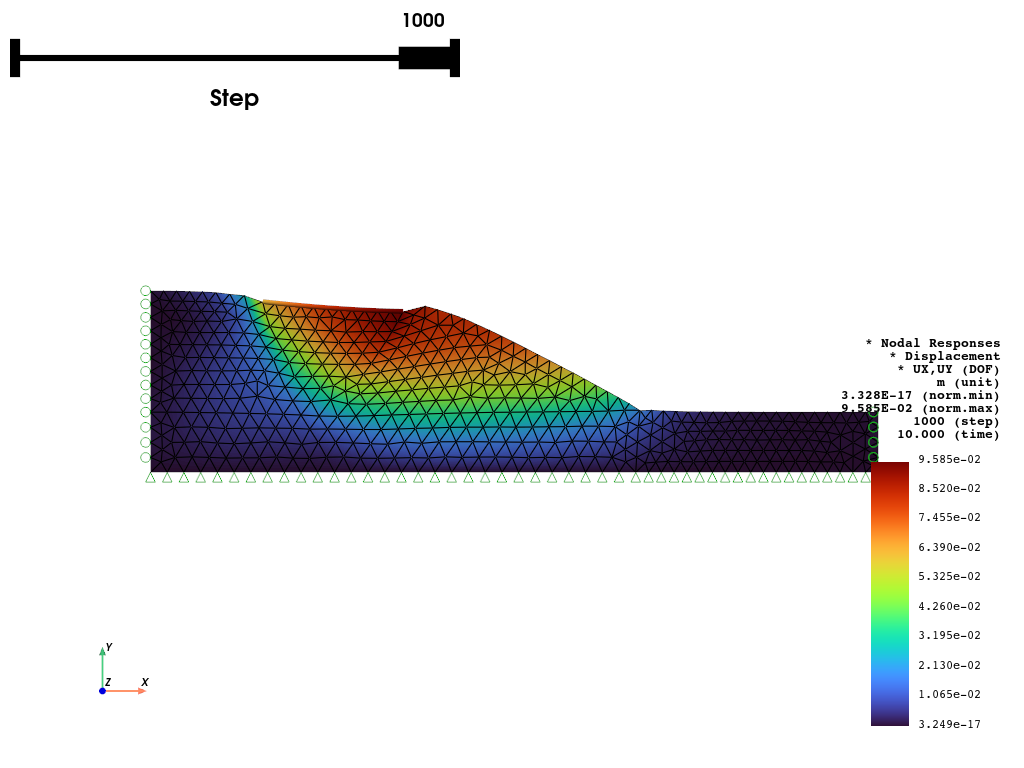

In [ ]:
opsvis.plot_nodal_responses(
    odb_tag="Slope_PDMY09_tri_enhanced",
    slides=True,
    defo_scale=20,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="juoyterlab")

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-Slope_PDMY09_tri.nc ...

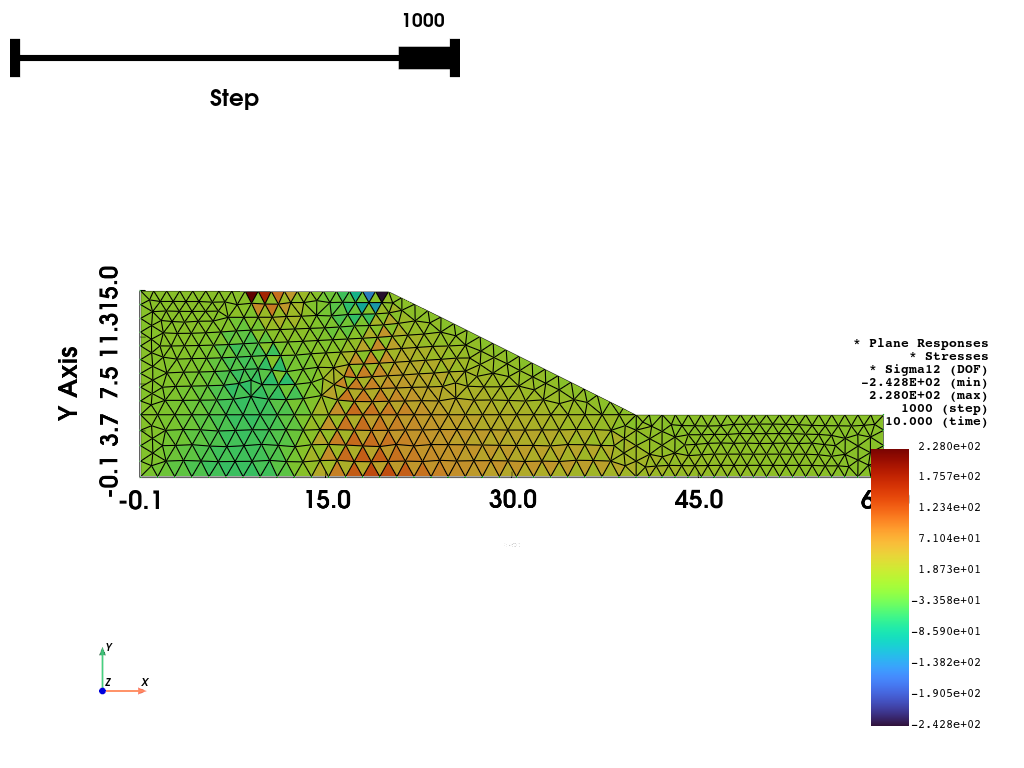

In [ ]:
pl = opsvis.plot_unstruct_responses(
    odb_tag="Slope_PDMY09_tri_enhanced", slides=True, ele_type="Plane", resp_type="stresses", resp_dof="sigma12",
    show_defo = True,
    defo_scale = 0.5,
    show_bc = True,
    bc_scale = 0.1,
    show_outline = True,
    show_model = True,
)
pl.show(jupyter_backend="jupyterlab")

In [ ]:
ele_resp = opst.post.get_element_responses(odb_tag="Slope_PDMY09_tri_enhanced", ele_type="Plane")
print("Data Variables in Element Responses:", ele_resp.data_vars)

OPSTOOL ::  Loading Plane response data from .opstool.output/RespStepData-Slope_PDMY09_tri.nc ...

Data Variables in Element Responses: Data variables:
    Stresses               (time, eleTags, GaussPoints, stressDOFs) float32 19MB ...
    Strains                (time, eleTags, GaussPoints, strainDOFs) float32 11MB ...
    StressesAtNodes        (time, nodeTags, stressDOFs) float32 11MB -86.59 ....
    StrainsAtNodes         (time, nodeTags, strainDOFs) float32 6MB 2.199e-05...
    StressAtNodesErr       (time, nodeTags, stressDOFs) float32 11MB 0.1638 ....
    StrainsAtNodesErr      (time, nodeTags, strainDOFs) float32 6MB 1.904 ......
    StressMeasures         (time, eleTags, GaussPoints, measures) float32 15MB ...
    StrainMeasures         (time, eleTags, GaussPoints, measures) float32 15MB ...
    StressMeasuresAtNodes  (time, nodeTags, measures) float32 9MB -86.35 ... ...
    StrainMeasuresAtNodes  (time, nodeTags, measures) float32 9MB 3.697e-05 ....


In [ ]:
print(ele_resp.stressDOFs.data)
print(ele_resp.strainDOFs.data)
print(ele_resp.measures.data)

['sigma11' 'sigma22' 'sigma12' 'sigma33' 'eta_r']
['eps11' 'eps22' 'eps12']
['p1' 'p2' 'sigma_vm' 'tau_max']


In [ ]:
node_check = 109

In [ ]:
sigma11 = ele_resp["Stresses"].sel(stressDOFs="sigma11", eleTags=node_check)
sigma22 = ele_resp["Stresses"].sel(stressDOFs="sigma22", eleTags=node_check)
sigma33 = ele_resp["Stresses"].sel(stressDOFs="sigma33", eleTags=node_check)
sigma12 = ele_resp["Stresses"].sel(stressDOFs="sigma12", eleTags=node_check)
eta_r = ele_resp["Stresses"].sel(stressDOFs="eta_r", eleTags=node_check)

In [ ]:
po = (sigma11 + sigma22 + sigma33) / 3.0
qo = (sigma11 - sigma22) ** 2 + (sigma22 - sigma33) ** 2 + (sigma33 - sigma11) ** 2 + 6 * (sigma12**2)
qo = np.sign(sigma12) * 1 / 3 * np.sqrt(qo)
print(qo)

<xarray.DataArray 'Stresses' (time: 1001, GaussPoints: 1)> Size: 4kB
array([[22.512419],
       [22.512363],
       [22.511679],
       ...,
       [47.918343],
       [47.936153],
       [47.961525]], shape=(1001, 1), dtype=float32)
Coordinates:
  * time         (time) float32 4kB 0.0 0.01 0.02 0.03 ... 9.97 9.98 9.99 10.0
    eleTags      int64 8B 109
  * GaussPoints  (GaussPoints) int64 8B 1
    stressDOFs   <U7 28B 'sigma12'


In [ ]:
eps11 = ele_resp["Strains"].sel(strainDOFs="eps11", eleTags=node_check)
eps22 = ele_resp["Strains"].sel(strainDOFs="eps22", eleTags=node_check)
eps12 = ele_resp["Strains"].sel(strainDOFs="eps12", eleTags=node_check)

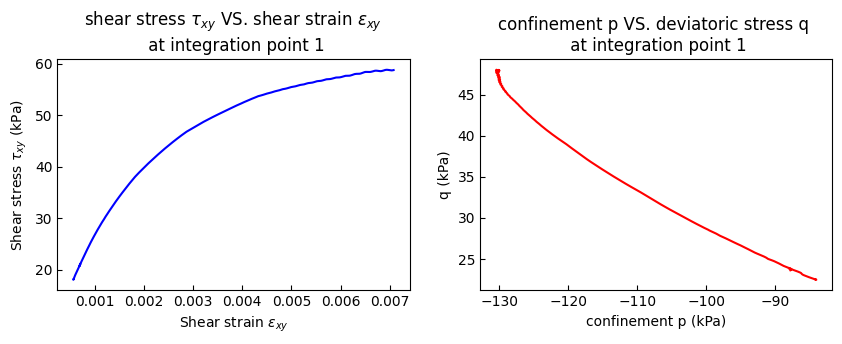

In [ ]:
eps12_ele1_1 = eps12.sel(GaussPoints=1)
sigma12_ele1_1 = sigma12.sel(GaussPoints=1)
po_ele1_1 = po.sel(GaussPoints=1)
qo_ele1_1 = qo.sel(GaussPoints=1)

fig, axs = plt.subplots(1, 2, figsize=(10, 3))
axs[0].plot(eps12_ele1_1, sigma12_ele1_1, "b")
axs[0].set_title("shear stress $\\tau_{xy}$ VS. shear strain $\\epsilon_{xy}$ \n at integration point 1")
axs[0].set_xlabel(r"Shear strain $\epsilon_{xy}$")
axs[0].set_ylabel(r"Shear stress $\tau_{xy}$ (kPa)")
axs[1].plot(po_ele1_1, qo_ele1_1, "r")
axs[1].set_title("confinement p VS. deviatoric stress q \n at integration point 1")
axs[1].set_xlabel("confinement p (kPa)")
axs[1].set_ylabel("q (kPa)")
plt.show()

In [ ]:
node_resp = opst.post.get_nodal_responses(odb_tag="Slope_PDMY09_tri_enhanced")
print(node_resp)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-Slope_PDMY09_tri.nc ...

<xarray.Dataset> Size: 81MB
Dimensions:             (time: 1001, nodeTags: 549, DOFs: 6)
Coordinates:
  * time                (time) float32 4kB 0.0 0.01 0.02 0.03 ... 9.98 9.99 10.0
  * nodeTags            (nodeTags) int64 4kB 1 2 3 4 5 6 ... 545 546 547 548 549
  * DOFs                (DOFs) <U2 48B 'UX' 'UY' 'UZ' 'RX' 'RY' 'RZ'
Data variables:
    disp                (time, nodeTags, DOFs) float32 13MB -5.852e-17 ... -0...
    vel                 (time, nodeTags, DOFs) float32 13MB 1.159e-36 ... -0....
    accel               (time, nodeTags, DOFs) float32 13MB 1.623e-41 ... -0....
    reaction            (time, nodeTags, DOFs) float32 13MB 58.52 ... 0.005531
    reactionIncInertia  (time, nodeTags, DOFs) float32 13MB 58.52 ... 3.846e-12
    rayleighForces      (time, nodeTags, DOFs) float32 13MB -2.719e-21 ... -0...
    pressure            (time, nodeTags) float32 2MB 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    UX:       Displacement in X direction
    UY:       Displacement in Y d

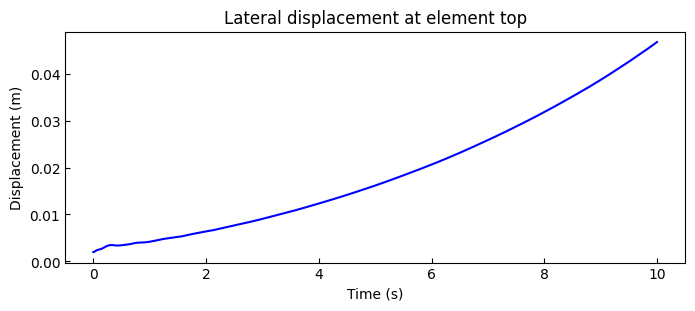

In [ ]:
#disp1 = node_resp["disp"].sel(nodeTags=485, DOFs="UX")
disp3 = node_resp["disp"].sel(nodeTags=113, DOFs="UX")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, disp3 , "b") #- disp1
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()

C:\Users\Michael Ocampo\AppData\Local\Temp\ipykernel_15252\3368819022.py:57: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)

C:\Users\Michael Ocampo\AppData\Local\Temp\ipykernel_15252\3368819022.py:58: DeprecationWarning:

Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)



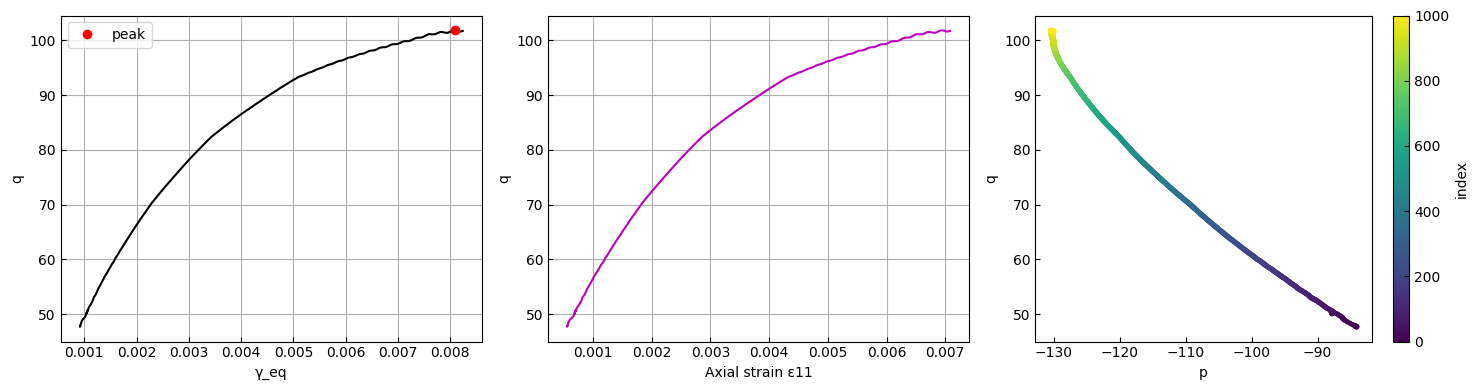

In [ ]:
"""
File: scripts/soil_backbone_plot.py

Now supports reading your .out stress and strain files (time + stress/strain values).
"""

import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, Dict, Optional

s11 = sigma11
s22 = sigma22
s33 = sigma33
s12 = sigma12

e11 = eps11
e22 = eps22
e12 = eps12

def trim_to_same_length(*arrays):
    arrays_np = [np.asarray(a) for a in arrays]
    min_len = min(len(a) for a in arrays_np)
    return [a[:min_len] for a in arrays_np]

def compute_p_q(s11, s22, s33, s12):
    s11, s22, s33, s12 = trim_to_same_length(s11, s22, s33, s12)
    p = (s11 + s22 + s33) / 3.0
    s1 = s11 - p
    s2 = s22 - p
    s3 = s33 - p
    s_dot_s = s1**2 + s2**2 + s3**2 + 2.0 * (s12**2)
    q = np.sqrt(1.5 * s_dot_s)
    return p, q

def compute_gamma_eq(e11, e22, e33, e12):
    e11, e22, e33, e12 = trim_to_same_length(e11, e22, e33, e12)
    eps_v = e11 + e22 + e33
    ed1 = e11 - eps_v / 3.0
    ed2 = e22 - eps_v / 3.0
    ed3 = e33 - eps_v / 3.0
    ed_dot_ed = ed1**2 + ed2**2 + ed3**2 + 2.0 * (e12**2)
    gamma_eq = np.sqrt(2.0/3.0 * ed_dot_ed)
    return eps_v, gamma_eq

def detect_peak_failure(q, gamma, drop_frac=0.1, lookahead=3):
    q = np.asarray(q)
    peak_idx = int(np.argmax(q))
    peak_q = q[peak_idx]
    thresh = (1.0 - drop_frac) * peak_q
    failure_idx = None
    for i in range(peak_idx + 1, len(q) - lookahead):
        if np.all(q[i:i+lookahead] < thresh):
            failure_idx = i
            break
    return {
        'peak_index': peak_idx,
        'peak_q': float(peak_q),
        'peak_gamma': float(gamma[peak_idx]) if len(gamma) > peak_idx else None,
        'failure_index': int(failure_idx) if failure_idx is not None else None,
        'failure_q': float(q[failure_idx]) if failure_idx is not None else None,
        'failure_gamma': float(gamma[failure_idx]) if (failure_idx is not None and len(gamma) > failure_idx) else None
    }

def plot_backbone(q, gamma, eps_axial=None, p=None, meta=None):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].plot(gamma, q, '-k', lw=1.5)
    if meta:
        peak = meta.get('peak_index')
        failure = meta.get('failure_index')
        if peak is not None:
            axes[0].plot(gamma[peak], q[peak], 'ro', label='peak')
        if failure is not None:
            axes[0].plot(gamma[failure], q[failure], 'bx', label='failure')
        axes[0].legend()
    axes[0].set_xlabel('γ_eq')
    axes[0].set_ylabel('q')
    axes[0].grid(True)
    if eps_axial is not None:
        eps_axial, q_ax = trim_to_same_length(eps_axial, q)
        axes[1].plot(eps_axial, q_ax, '-m')
        axes[1].set_xlabel('Axial strain ε11')
        axes[1].set_ylabel('q')
        axes[1].grid(True)
    else:
        axes[1].axis('off')
    if p is not None:
        p, q_p = trim_to_same_length(p, q)
        sc = axes[2].scatter(p, q_p, c=np.arange(len(q_p)), cmap='viridis', s=8)
        axes[2].set_xlabel('p')
        axes[2].set_ylabel('q')
        plt.colorbar(sc, ax=axes[2], label='index')
    else:
        axes[2].axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    e33 = -(e11 + e22)
    p, q = compute_p_q(s11, s22, s33, s12)
    eps_v, gamma = compute_gamma_eq(e11, e22, e33, e12)
    meta = detect_peak_failure(q, gamma)
    plot_backbone(q, gamma, eps_axial=e12, p=p, meta=meta)
